In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [17]:
DATA_PATH = Path("../data/raw/mvtec_ad")

categories = sorted([p.name for p in DATA_PATH.iterdir() if p.is_dir()])
categories

['bottle', 'cable', 'capsule', 'hazelnut', 'screw']

In [18]:
rows = []

for category in categories:
    category_path = DATA_PATH / category

    for split in ["train", "test", "ground_truth"]:
        split_path = category_path / split

        if not split_path.exists():
            continue

        for defect_type_path in sorted(split_path.iterdir()):
            if not defect_type_path.is_dir():
                continue

            image_count = len(list(defect_type_path.glob("*.png")))

            rows.append({
                "category": category,
                "split": split,
                "defect_type": defect_type_path.name,
                "count": image_count,
            })

counts = pd.DataFrame(rows)
counts.head(10)


,category,split,defect_type,count
0,bottle,train,good,209
1,bottle,test,broken_large,20
2,bottle,test,broken_small,22
3,bottle,test,contamination,21
4,bottle,test,good,20
5,bottle,ground_truth,broken_large,20
6,bottle,ground_truth,broken_small,22
7,bottle,ground_truth,contamination,21
8,cable,train,good,224
9,cable,test,bent_wire,13


In [19]:
train_good = counts.query("split == 'train' and defect_type == 'good'").set_index("category")["count"]
test_good = counts.query("split == 'test' and defect_type == 'good'").set_index("category")["count"]

test_defects = (
    counts.query("split == 'test' and defect_type != 'good'")
    .groupby("category")["count"]
    .sum()
)

mask_count = (
    counts.query("split == 'ground_truth'")
    .groupby("category")["count"]
    .sum()
)

num_defect_types = (
    counts.query("split == 'test' and defect_type != 'good'")
    .groupby("category")["defect_type"]
    .nunique()
)

summary = pd.DataFrame({
    "train_good": train_good,
    "test_good": test_good,
    "test_defective": test_defects,
    "ground_truth_masks": mask_count,
    "defect_types": num_defect_types,
}).fillna(0).astype(int)

summary

,train_good,test_good,test_defective,ground_truth_masks,defect_types
category,,,,,
bottle,209,20,63,63,3
cable,224,58,92,92,8
capsule,219,23,109,109,5
hazelnut,391,40,70,70,4
screw,320,41,119,119,5


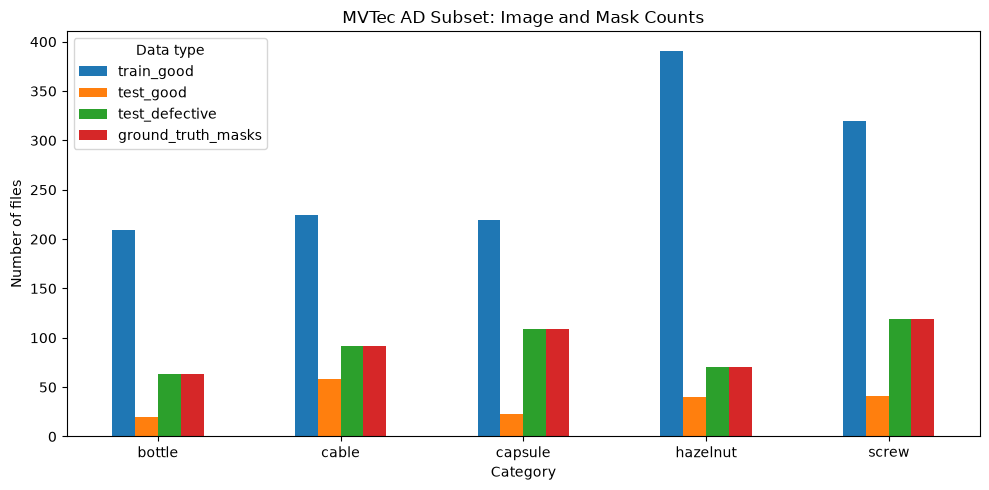

In [20]:
ax = summary[["train_good", "test_good", "test_defective", "ground_truth_masks"]].plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("MVTec AD Subset: Image and Mask Counts")
ax.set_xlabel("Category")
ax.set_ylabel("Number of files")
ax.legend(title="Data type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
category = "bottle"
defect_type = "broken_small"
image_id = "000"

normal_path = DATA_PATH / category / "train" / "good" / f"{image_id}.png"
defect_path = DATA_PATH / category / "test" / defect_type / f"{image_id}.png"
mask_path = DATA_PATH / category / "ground_truth" / defect_type / f"{image_id}_mask.png"

normal = Image.open(normal_path)
defect = Image.open(defect_path)
mask = Image.open(mask_path)

normal.mode, normal.size, defect.mode, defect.size, mask.mode, mask.size

('RGB', (900, 900), 'RGB', (900, 900), 'L', (900, 900))

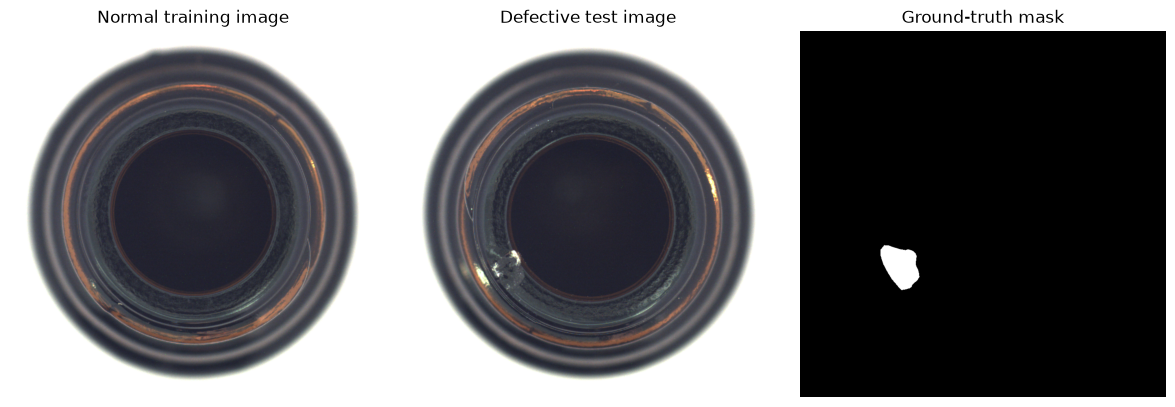

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(normal)
axes[0].set_title("Normal training image")
axes[0].axis("off")

axes[1].imshow(defect)
axes[1].set_title("Defective test image")
axes[1].axis("off")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Ground-truth mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

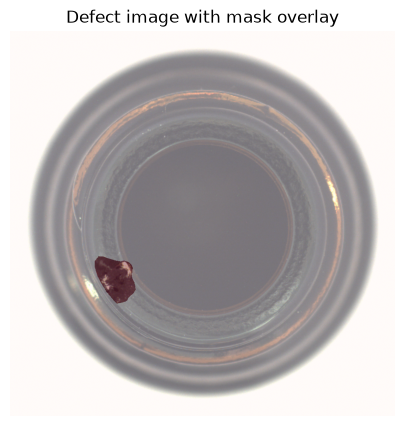

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(defect)
ax.imshow(mask, cmap="Reds", alpha=0.4)
ax.set_title("Defect image with mask overlay")
ax.axis("off")

plt.show()

## Observations

- Normal training image contains no visible defect.
- Defective test image contains a localized abnormal region.
- Ground truth mask marks the defective pixels in white.
- Overlay confirms that the mask is spatially aligned with the defective image.

In [28]:
example_rows = []
for category in categories:
    test_path = DATA_PATH / category / "test"

    defect_types = sorted([
        p.name for p in test_path.iterdir()
        if p.is_dir() and p.name != "good"
    ])
    defect_type = defect_types[0]
    image_path = sorted((test_path / defect_type).glob("*.png"))[0]
    image_id = image_path.stem
    mask_path = (
        DATA_PATH
        / category
        / "ground_truth"
        / defect_type
        / f"{image_id}_mask.png"
    )
    example_rows.append({
        "category": category,
        "defect_type": defect_type,
        "image_path": image_path,
        "mask_path": mask_path,
    })
examples = pd.DataFrame(example_rows)
examples[["category", "defect_type"]]

,category,defect_type
0,bottle,broken_large
1,cable,bent_wire
2,capsule,crack
3,hazelnut,crack
4,screw,manipulated_front


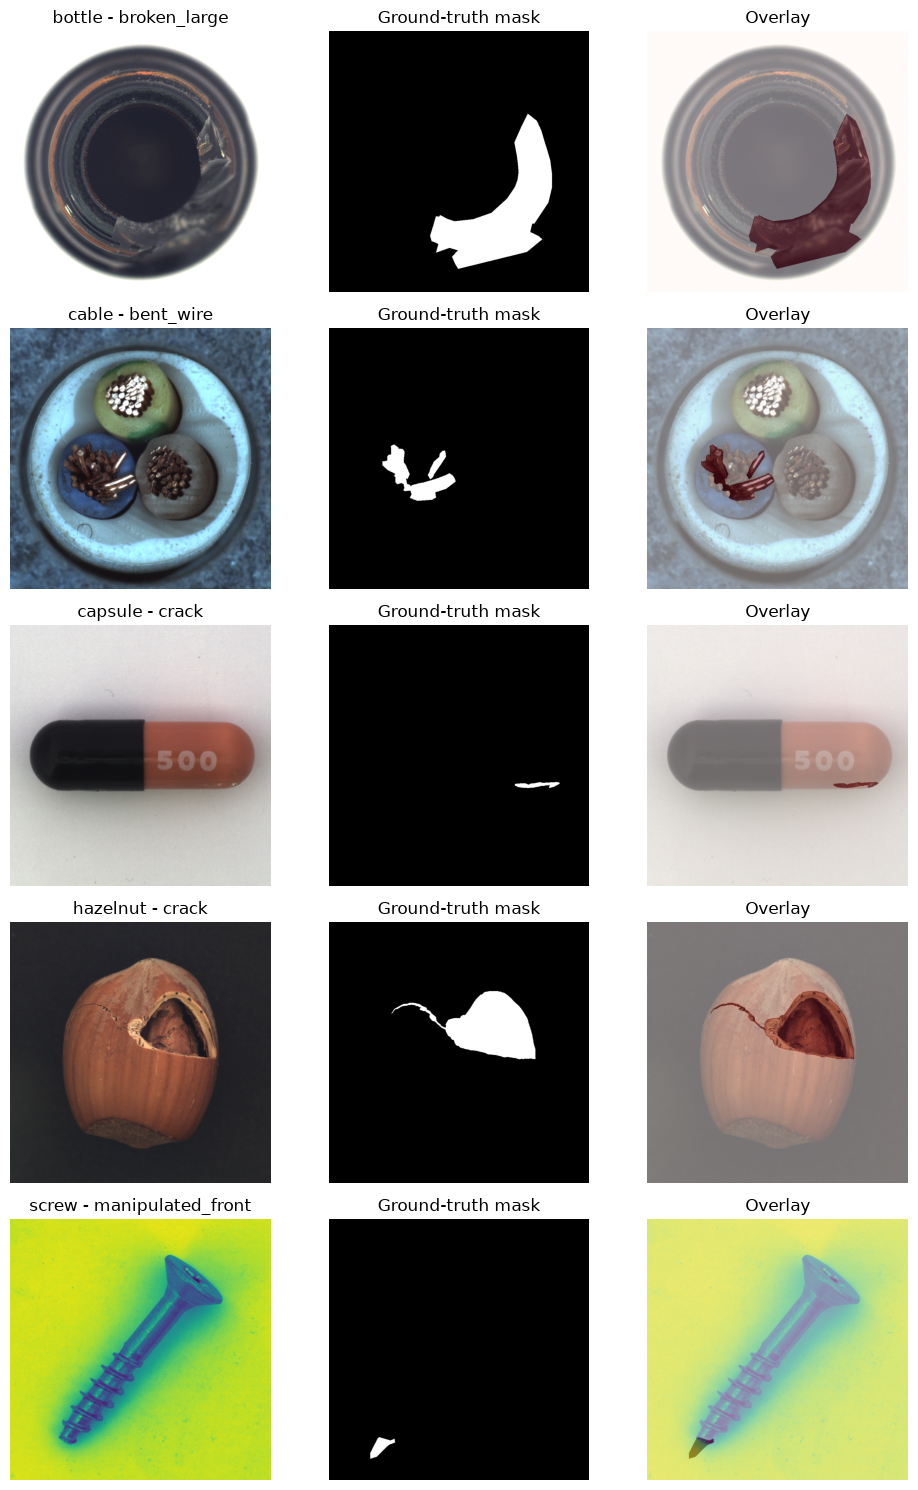

In [29]:
fig, axes = plt.subplots(len(examples), 3, figsize=(10, 3 * len(examples)))

for row_idx, row in examples.iterrows():
    image = Image.open(row["image_path"])
    mask = Image.open(row["mask_path"])
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(f"{row['category']} - {row['defect_type']}")
    axes[row_idx, 0].axis("off")
    axes[row_idx, 1].imshow(mask, cmap="gray")
    axes[row_idx, 1].set_title("Ground-truth mask")
    axes[row_idx, 1].axis("off")
    axes[row_idx, 2].imshow(image)
    axes[row_idx, 2].imshow(mask, cmap="Reds", alpha=0.4)
    axes[row_idx, 2].set_title("Overlay")
    axes[row_idx, 2].axis("off")
plt.tight_layout()
plt.show()

## Cross-Category Observations

- Bottle defects are relatively easy to inspect because the object shape is simple.
- Cable and screw appear more complex because their geometry is less uniform.
- Some masks cover small regions, which makes pixel-level localization harder.